# 02 — Scalar-porosity pretraining

**Series:** field-controlled generation in 2D · notebook 2 of 5

Before the model can obey a *field*, it learns to obey a *number*. This notebook trains a
latent diffusion model on $256^2$ Berea patches, conditioned on the scalar porosity of
each patch. It is the 2D mirror of **Algorithm 1** of Part II (and of the Part I
"controlling" experiments), and its checkpoint is the starting point that notebook 03
fine-tunes.

There is one architectural observation that makes the entire method work, and it is worth
stating before any training happens:

> **The conditioning embedder does not care about spatial shape.**
> `ScalarEmbedder` maps a batch of scalars `[B] -> [B, C]` and a batch of *fields*
> `[B, H, W] -> [B, C, H, W]`, using the same weights. Feeding a field instead of a scalar
> therefore requires **no architectural change at all** — only different data.

So this notebook is not a detour. It trains the exact network that notebook 03 will
re-use, and §3 below demonstrates the shape-agnosticism directly.

---
## 1. Setup

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import os
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
import lightning
import lightning.pytorch.callbacks as pl_callbacks

import diffsci2.data
import diffsci2.models
import diffsci2.nets

import fcconfig as fc

fc.ensure_dirs()
torch.manual_seed(0)
np.random.seed(0)

DEVICE = fc.DEVICE
print(f"device              = {DEVICE}")
print(f"training patch      = {fc.PATCH}^2  ->  latent {fc.LATENT_PATCH}^2 x {fc.Z_DIM}")

device              = cuda:2
training patch      = 256^2  ->  latent 32^2 x 4


In [19]:
# --- training knobs ---
BATCH_SIZE = 16
DATASET_SIZE = 2 ** 12       # patches per epoch
MAX_EPOCHS = 60
LR = 2e-4
WARMUP_STEPS = 500

RETRAIN = False
CKPT = os.path.join(fc.SCALAR_CKPT_DIR, "last.ckpt")
print(f"checkpoint -> {CKPT}   (exists: {os.path.exists(CKPT)})")

checkpoint -> /home/ubuntu/repos/DiffSci2/notebooks/tutorials/fieldcontrolling/fcdata/checkpoints/scalar/last.ckpt   (exists: True)


---
## 2. Paired data: patch $\to$ its own porosity

The label is not external metadata — it is *computed from the patch itself*:
$y = \operatorname{mean}(1 - \omega)$. That is what makes the conditioning learnable from a
single rock with no annotation.

We use the training slices only (`[0:TRAIN_SLICES]`), holding the rest back for validation,
mirroring the thesis's $(1000,1000,700)$ / $(1000,1000,300)$ split.

In [20]:
slices = fc.load_slices()                 # uint8 [N, 1000, 1000], solid = 1
train_volume = np.ascontiguousarray(slices[:fc.TRAIN_SLICES])
val_volume = np.ascontiguousarray(slices[fc.TRAIN_SLICES:])
print(f"train {train_volume.shape}   val {val_volume.shape}")


class ScalarPorosityDataset(torch.utils.data.Dataset):
    '''Random patch + the scalar porosity of that same patch.

    Mirrors lines 4-7 of Algorithm 1: sample a position, augment, compute
    y = mean(1 - omega), then hand (x, y) to the denoising loss.
    '''

    def __init__(self, volume, dataset_size, patch=fc.PATCH, symmetry=None):
        self.volume = volume
        self.dataset_size = dataset_size
        self.patch = patch
        self.symmetry = symmetry
        self.rng = np.random.default_rng()

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):
        s = self.rng.integers(0, self.volume.shape[0])
        i = self.rng.integers(0, self.volume.shape[1] - self.patch + 1)
        j = self.rng.integers(0, self.volume.shape[2] - self.patch + 1)
        patch = self.volume[s, i:i + self.patch, j:j + self.patch].copy()

        x = torch.from_numpy(patch).float()
        if self.symmetry is not None:
            x = self.symmetry.apply(x, int(self.rng.integers(0, 8)))

        porosity = 1.0 - x.mean()          # <- the conditioning signal
        return {'x': x.unsqueeze(0), 'y': {'porosity': porosity}}


symmetry = diffsci2.data.SquareSymmetry()
train_dataset = ScalarPorosityDataset(train_volume, DATASET_SIZE, symmetry=symmetry)
val_dataset = ScalarPorosityDataset(val_volume, DATASET_SIZE // 4, symmetry=None)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4,
    pin_memory=True, drop_last=True, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
    pin_memory=True, persistent_workers=True)

batch = next(iter(train_loader))
print(f"x {tuple(batch['x'].shape)}   y['porosity'] {tuple(batch['y']['porosity'].shape)}")

train (120, 1000, 1000)   val (40, 1000, 1000)
x (16, 1, 256, 256)   y['porosity'] (16,)


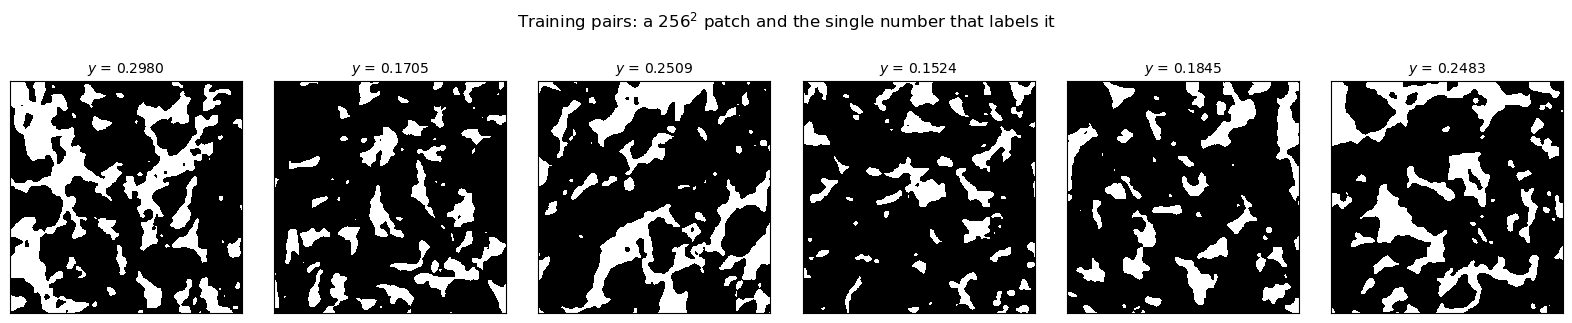

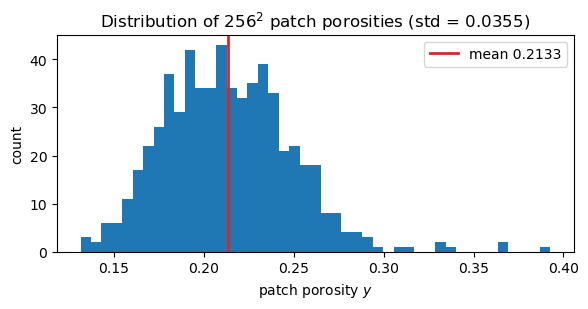

In [21]:
fig, axes = plt.subplots(1, 6, figsize=(16, 3.0))
for ax, img, p in zip(axes, batch['x'], batch['y']['porosity']):
    ax.imshow(img[0], cmap='gray_r', interpolation='nearest')
    ax.set_title(f"$y$ = {p:.4f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Training pairs: a $256^2$ patch and the single number that labels it", y=1.06)
fig.tight_layout()
fc.savefig(fig, "02_scalar_training_pairs")
plt.show()

# The spread of the labels *is* the heterogeneity the field model will later resolve.
labels = np.array([train_dataset[i]['y']['porosity'].item() for i in range(600)])
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(labels, bins=45, color='C0')
ax.axvline(labels.mean(), color='C3', lw=2, label=f"mean {labels.mean():.4f}")
ax.set_xlabel("patch porosity $y$"); ax.set_ylabel("count")
ax.set_title(f"Distribution of $256^2$ patch porosities (std = {labels.std():.4f})")
ax.legend(); fig.tight_layout()
fc.savefig(fig, "02_label_distribution")
plt.show()

---
## 3. The embedder is shape-agnostic — the load-bearing observation

`ScalarEmbedder` applies a Gaussian Fourier projection followed by an MLP **pointwise**.
If the input has spatial dimensions, they simply come along for the ride:

```
[B]        -> gaussian_proj -> MLP ->  [B, C]              (scalar conditioning)
[B, H, W]  -> gaussian_proj -> MLP ->  [B, C, H, W]        (field conditioning)
```

Inside the U-Net the conditioning embedding is added to the time embedding and then
injected into every residual block. When the embedding carries spatial dimensions that
do not match the current feature-map resolution, `ResnetBlockC.rescale_yt` pools or
upsamples it to fit — which is precisely the thesis sentence *"we use field downsampling
in the lower layers of the UNet to match the spatial representation at these layers."*

Let us verify all of that on the untrained network, before committing to a training run.

In [22]:
probe_embedder = diffsci2.nets.ScalarEmbedder(dembed=fc.MODEL_CHANNELS, key='porosity')

scalar_in = {'porosity': torch.rand(4)}
field_in = {'porosity': torch.rand(4, fc.LATENT_PATCH, fc.LATENT_PATCH)}
print(f"scalar {tuple(scalar_in['porosity'].shape)}  ->  {tuple(probe_embedder(scalar_in).shape)}")
print(f"field  {tuple(field_in['porosity'].shape)}  ->  {tuple(probe_embedder(field_in).shape)}")
print("\nSame module, same weights. Only the input rank changed.")

scalar (4,)  ->  (4, 64)
field  (4, 32, 32)  ->  (4, 64, 32, 32)

Same module, same weights. Only the input rank changed.


In [23]:
# And the full denoiser accepts all three conditioning modes with identical weights.
probe_model = fc.make_flow_model(conditional=True)
zt = torch.randn(2, fc.Z_DIM, fc.LATENT_PATCH, fc.LATENT_PATCH)
t = torch.rand(2)

with torch.no_grad():
    out_scalar = probe_model(zt, t, {'porosity': torch.rand(2)})
    out_field = probe_model(zt, t, {'porosity': torch.rand(2, fc.LATENT_PATCH, fc.LATENT_PATCH)})
    out_none = probe_model(zt, t, None)

print(f"denoiser params        : {sum(p.numel() for p in probe_model.parameters()) / 1e6:.2f}M")
print(f"scalar conditioning    : {tuple(out_scalar.shape)}")
print(f"field  conditioning    : {tuple(out_field.shape)}")
print(f"no     conditioning    : {tuple(out_none.shape)}   <- the implicit unconditional model")
del probe_model, probe_embedder

denoiser params        : 11.15M
scalar conditioning    : (2, 4, 32, 32)
field  conditioning    : (2, 4, 32, 32)
no     conditioning    : (2, 4, 32, 32)   <- the implicit unconditional model


> **Divergence worth flagging.** The thesis describes "a conditional dropout of $0.1$ to
> implicitly obtain a trained unconditional model". In the code, `PUNetGConfig.cond_dropout`
> is a plain `torch.nn.Dropout` applied to the conditioning *embedding vector* — element-wise
> feature dropout, not the classifier-free-guidance null-token dropout (`cond_drop`, a
> separate and unused option). The unconditional model of the thesis is obtained at
> inference time by rebuilding the same weights **without** the embedder and passing
> `y=None`, which is what `0004e-porosity-field-generator.py` does for generation case 7.
> We keep the production configuration verbatim so the tutorial mirrors the real pipeline,
> and we reproduce that unconditional baseline the same way in §6.

---
## 4. Train

The model is a `PUNetG` denoiser operating in the frozen VAE's latent space, wrapped in an
`SIModule` with the EDM sigma-space parameterisation
($\sigma_{\min}=0.002$, $\sigma_{\max}=80$, $\sigma_{\text{data}}=0.5$) — identical settings
to the production pipeline. The loss is the denoising objective

$$\mathcal{L}(\theta) = \mathbb{E}_{\sigma, y}\,\mathbb{E}_{z\sim q(z|y)}\,\mathbb{E}_{z_\sigma}\bigl\lVert D_\theta(z_\sigma,\sigma,y) - z \bigr\rVert^2 .$$

The autoencoder is passed to the module (so `loss_fn` encodes each batch on the fly) but
**only the denoiser's parameters go to the optimiser**, exactly as in
`0003-porosity-field-training.py`.

In [24]:
vae = fc.load_vae(device=None)          # built on CPU; SIModule moves it with the rest
flow_model = fc.make_flow_model(conditional=True)
flow_module = fc.make_si_module(flow_model, autoencoder=vae)
flow_module.freeze_autoencoder()

n_train = sum(p.numel() for p in flow_module.model.parameters())
n_frozen = sum(p.numel() for p in flow_module.autoencoder.parameters())
print(f"trainable (denoiser) : {n_train / 1e6:.2f}M")
print(f"frozen    (VAE)      : {n_frozen / 1e6:.2f}M")

trainable (denoiser) : 11.15M
frozen    (VAE)      : 5.12M


In [25]:
if RETRAIN or not os.path.exists(CKPT):
    optimizer = torch.optim.AdamW(
        flow_module.model.parameters(), lr=LR, betas=(0.9, 0.999),
        weight_decay=0.01, eps=1e-8)

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda step: min(1.0, (step + 1) / WARMUP_STEPS))
    flow_module.set_optimizer_and_scheduler(
        optimizer=optimizer, scheduler=scheduler, scheduler_interval="step")

    trainer = lightning.Trainer(
        max_epochs=MAX_EPOCHS,
        default_root_dir=fc.SCALAR_CKPT_DIR,
        gradient_clip_val=1.0,
        callbacks=[
            diffsci2.models.NanToZeroGradCallback(),
            pl_callbacks.ModelCheckpoint(
                dirpath=fc.SCALAR_CKPT_DIR,
                filename='scalar-{epoch:03d}-{val_loss:.5f}',
                monitor='val_loss', mode='min', save_top_k=2, save_last=True),
            pl_callbacks.LearningRateMonitor(logging_interval='step'),
        ],
        devices=[int(DEVICE.split(':')[1])],
        precision='16-mixed',
        logger=lightning.pytorch.loggers.CSVLogger(fc.SCALAR_CKPT_DIR, name='logs'),
        log_every_n_steps=20,
    )
    t0 = time.time()
    trainer.fit(flow_module, train_loader, val_loader)
    print(f"trained in {(time.time() - t0) / 60:.1f} min")
else:
    print("checkpoint found, skipping training (set RETRAIN = True to force)")

checkpoint found, skipping training (set RETRAIN = True to force)


In [26]:
# Reload cleanly from the checkpoint, so this section is reproducible on its own.
flow_model = fc.load_flow_model(CKPT, conditional=True)
vae = fc.load_vae()
sampler_module = fc.make_si_module(flow_model, autoencoder=vae).to(DEVICE).eval()
print("scalar-conditioned model ready")

scalar-conditioned model ready


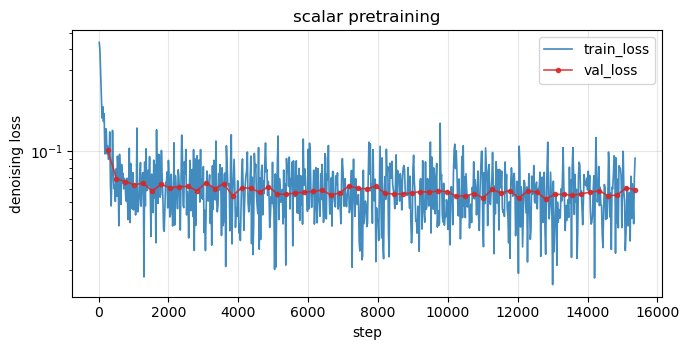

In [27]:
# Loss curves, if the run was done in this session.
import glob
import pandas as pd

logs = sorted(glob.glob(os.path.join(fc.SCALAR_CKPT_DIR, 'logs', '*', 'metrics.csv')))
if logs:
    dfm = pd.read_csv(logs[-1])
    fig, ax = plt.subplots(figsize=(7, 3.6))
    for col, style in [('train_loss', 'C0-'), ('val_loss', 'C3o-')]:
        if col in dfm.columns:
            sub = dfm[['step', col]].dropna()
            ax.plot(sub['step'], sub[col], style, lw=1.2, ms=3, label=col, alpha=0.85)
    ax.set_xlabel("step"); ax.set_ylabel("denoising loss"); ax.set_yscale('log')
    ax.legend(); ax.grid(alpha=0.3); ax.set_title("scalar pretraining")
    fig.tight_layout()
    fc.savefig(fig, "02_loss_curves")
    plt.show()
else:
    print("no CSV logs in this directory")

---
## 5. Does the control actually work?

The test that matters: **ask for a porosity, measure what comes out.** We sweep the
requested value $y$ across the range seen in training and generate several samples at
each setting.

Sampling is the probability-flow ODE integrated from $\sigma_{\max}=80$ to
$\sigma_{\min}=0.002$ with Heun's method (21 steps), conditioned on $y$; the resulting
latent is decoded and binarised with the mean threshold.

In [28]:
@torch.no_grad()
def generate_scalar(module, porosity_value, n=1, latent_size=fc.LATENT_PATCH,
                    nsteps=fc.NSTEPS, seed=None):
    '''Generate n binary images conditioned on a single scalar porosity.'''
    if seed is not None:
        torch.manual_seed(seed)
    out = []
    for _ in range(n):
        y = None
        if porosity_value is not None:
            y = {'porosity': torch.tensor([porosity_value], dtype=torch.float32)}
        img = module.sample(1, shape=[fc.Z_DIM, latent_size, latent_size], y=y,
                            nsteps=nsteps, is_latent_shape=True,
                            return_latents=False, guidance=1.0)
        arr = img[0, 0].cpu().numpy()
        out.append((arr > arr.mean()).astype(np.float32))
    return out


requested = [0.10, 0.14, 0.18, 0.22, 0.26, 0.30]
N_PER = 4

t0 = time.time()
results = {p: generate_scalar(sampler_module, p, n=N_PER, seed=1234) for p in requested}
print(f"generated {len(requested) * N_PER} images in {time.time() - t0:.0f}s")

# Convention: generate_scalar returns solid = 1, so porosity = 1 - mean.
achieved = {p: [float(1 - im.mean()) for im in imgs] for p, imgs in results.items()}
for p in requested:
    vals = achieved[p]
    print(f"  requested {p:.2f}  ->  achieved {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

/opt/persistence/repos/DiffSci2/diffsci2/models/karras/flowfield.py:897: UserWarning: Moving y to device: cuda:2
  warnings.warn("Moving y to device: {}".format(self.device))


generated 24 images in 9s
  requested 0.10  ->  achieved 0.3297 +/- 0.0051
  requested 0.14  ->  achieved 0.1592 +/- 0.0062
  requested 0.18  ->  achieved 0.1806 +/- 0.0044
  requested 0.22  ->  achieved 0.2121 +/- 0.0052
  requested 0.26  ->  achieved 0.2430 +/- 0.0035
  requested 0.30  ->  achieved 0.2478 +/- 0.0029


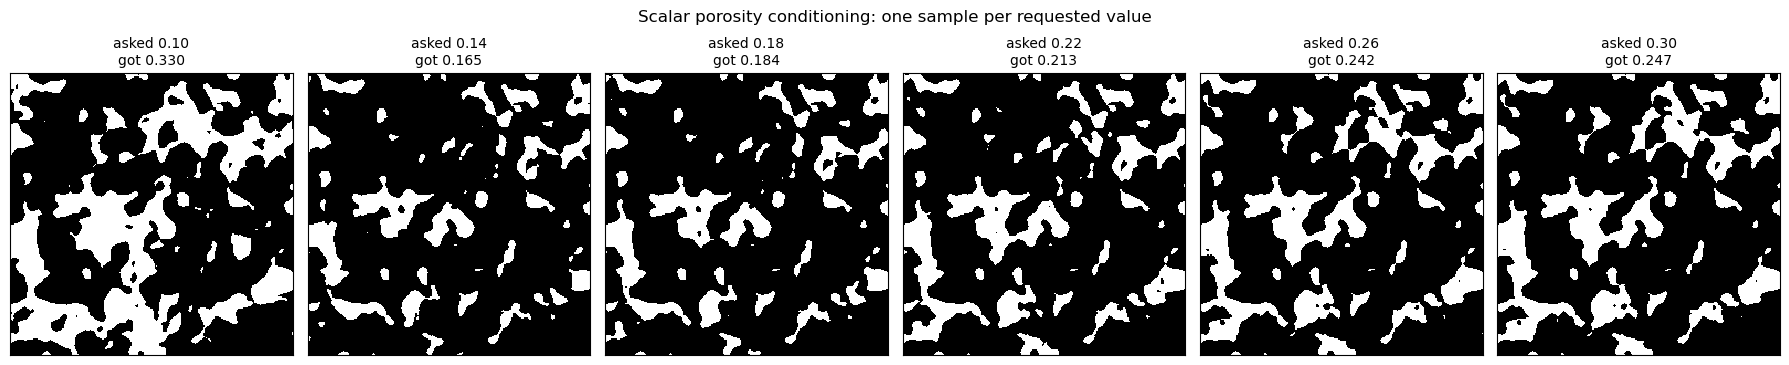

In [29]:
fig, axes = plt.subplots(1, len(requested), figsize=(3.0 * len(requested), 3.5))
for ax, p in zip(axes, requested):
    im = results[p][0]
    ax.imshow(im, cmap='gray_r', interpolation='nearest')
    ax.set_title(f"asked {p:.2f}\ngot {1 - im.mean():.3f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Scalar porosity conditioning: one sample per requested value", y=1.04)
fig.tight_layout()
fc.savefig(fig, "02_scalar_control_gallery")
plt.show()

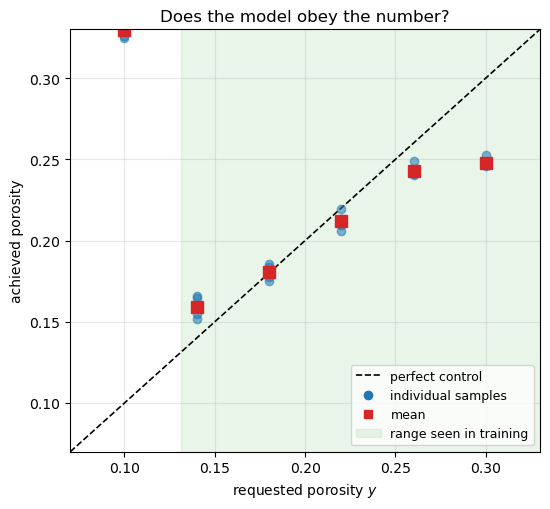

In [30]:
fig, ax = plt.subplots(figsize=(5.6, 5.2))
lo, hi = min(requested) - 0.03, max(requested) + 0.03
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='perfect control')
for p in requested:
    vals = achieved[p]
    ax.plot([p] * len(vals), vals, 'o', color='C0', alpha=0.55, ms=6)
    ax.plot(p, np.mean(vals), 's', color='C3', ms=9)
ax.plot([], [], 'o', color='C0', label='individual samples')
ax.plot([], [], 's', color='C3', label='mean')
ax.axvspan(labels.min(), labels.max(), color='C2', alpha=0.10,
           label='range seen in training')
ax.set_xlabel("requested porosity $y$"); ax.set_ylabel("achieved porosity")
ax.set_title("Does the model obey the number?")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fc.savefig(fig, "02_scalar_control_curve")
plt.show()

This is the "controlling" result of Part I, and it is also the warning that motivates
Part II. The model obeys a scalar — but a scalar is a **spatially uniform** instruction.
Ask a $1024^2$ image for "porosity 0.22" and you get an image that is uniformly 0.22
everywhere, with none of the large-scale heterogeneity a real rock has. That failure mode
is the thesis's **Controlled** baseline, and it is exactly what the field fixes.

---
## 6. The implicit unconditional model

Rebuilding the *same weights* without the conditioning embedder and passing `y=None`
gives the unconditional model — the thesis's **Uncond** baseline (generation case 7).
No separate training run is involved.

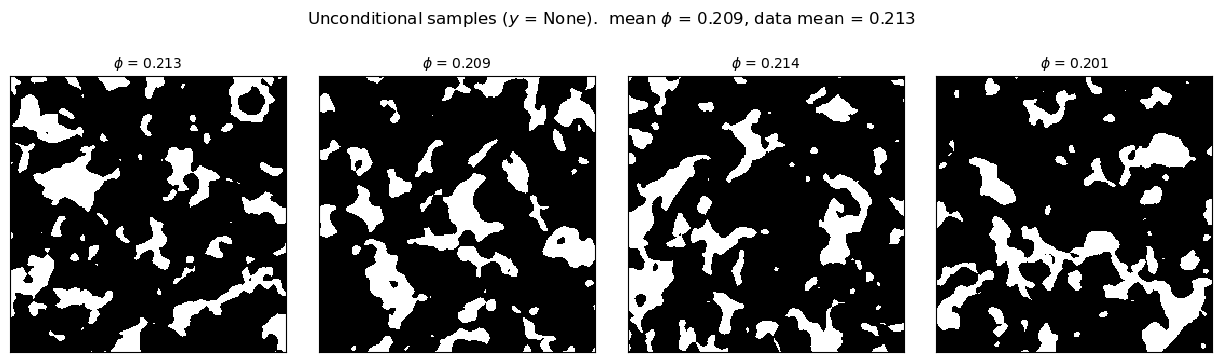

In [31]:
uncond_model = fc.load_flow_model(CKPT, conditional=False)
uncond_module = fc.make_si_module(uncond_model, autoencoder=fc.load_vae()).to(DEVICE).eval()

uncond_imgs = generate_scalar(uncond_module, None, n=4, seed=7)
uncond_por = [1 - im.mean() for im in uncond_imgs]

fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.4))
for ax, im in zip(axes, uncond_imgs):
    ax.imshow(im, cmap='gray_r', interpolation='nearest')
    ax.set_title(f"$\\phi$ = {1 - im.mean():.3f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Unconditional samples ($y$ = None).  mean $\\phi$ = {np.mean(uncond_por):.3f}, "
             f"data mean = {labels.mean():.3f}", y=1.05)
fig.tight_layout()
fc.savefig(fig, "02_unconditional_samples")
plt.show()

---
## 7. What the denoiser is actually doing

A useful slide: at each step of the ODE we can show both the **noisy latent** $z_\sigma$
being fed to the network and the network's **prediction of the clean latent**
$D_\theta(z_\sigma,\sigma,y)$, decoded to pixel space. The noisy state changes smoothly
because each step is small; the prediction changes dramatically, because the model's idea
of "the clean answer" sharpens as $\sigma$ falls.

In [32]:
@torch.no_grad()
def denoising_history(module, porosity_value, latent_size=fc.LATENT_PATCH,
                      n_steps=fc.NSTEPS, seed=0):
    module.eval()
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    z = torch.randn(1, fc.Z_DIM, latent_size, latent_size, generator=g, device=DEVICE)

    schedule = module.create_time_schedule(n_steps).to(DEVICE)
    sigmas = [module.config.sigma_fn(t).item() for t in schedule]
    z = z * module.config.sigma_fn(schedule[0])

    # Shape [1, 1], not [1]: we are calling the denoiser directly, so we bypass the
    # dict_unsqueeze that SIModule.sample() applies. ScalarEmbedder squeezes a
    # trailing dim of size 1, and a bare [1] would collapse to a 0-dim tensor.
    y = {'porosity': torch.tensor([[porosity_value]], device=DEVICE)}
    noisy, predicted = [], []
    for i in range(len(schedule)):
        t_i = schedule[i] * torch.ones(1, device=DEVICE)
        denoised = module.get_denoised_estimate(z, t_i, y=y, guidance=1.0)
        noisy.append(z.clone())
        predicted.append(denoised.clone())
        if i == len(schedule) - 1:
            break
        t_next = schedule[i + 1] * torch.ones(1, device=DEVICE)
        method = 'euler' if i == len(schedule) - 2 else 'heun'
        z = module.integration_step(z, t_i, t_next, y=y, guidance=1.0, method=method)
    return sigmas, noisy, predicted


sigmas, noisy, predicted = denoising_history(sampler_module, 0.22, seed=3)
print(f"sigma from {sigmas[0]:.1f} down to {sigmas[-1]:.4f} in {len(sigmas)} steps")

sigma from 80.0 down to 0.0020 in 21 steps


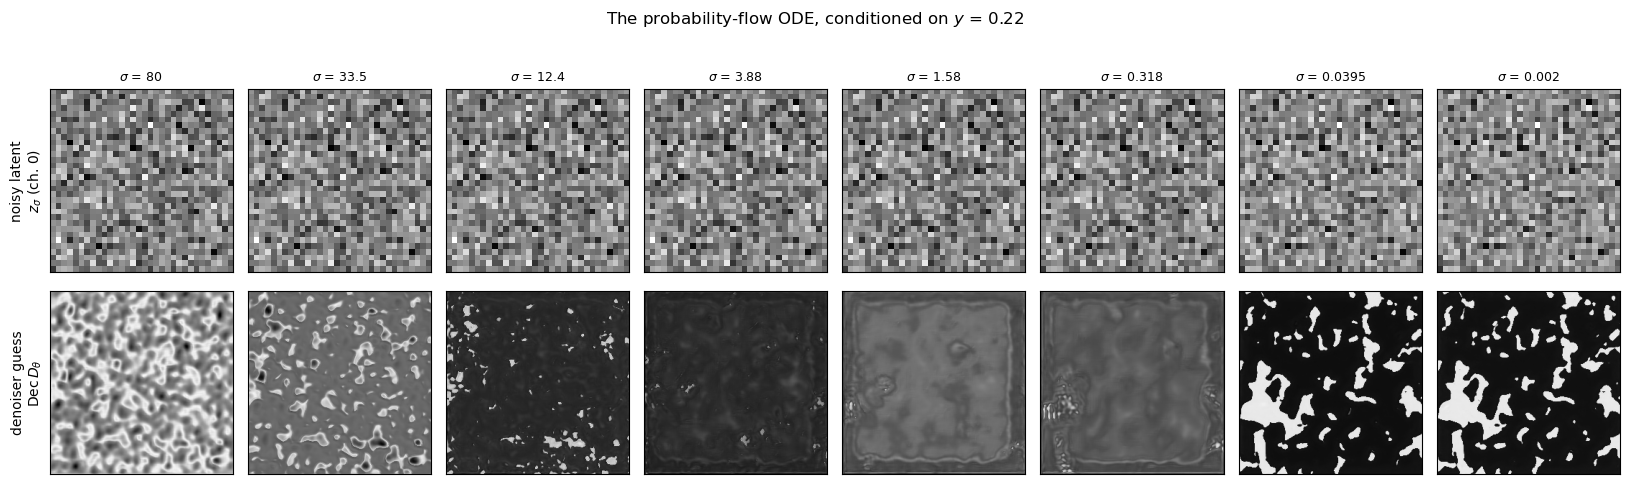

In [33]:
show = np.unique(np.round(np.linspace(0, len(sigmas) - 1, 8)).astype(int))

# The ODE runs on *normalised* latents (SIModule divides by initial_norm = 20 when
# encoding, and only undoes it at the very end of integrate_flow_field). The
# intermediate denoiser estimates are therefore still normalised, so we must unnorm
# them before handing them to the VAE decoder.
with torch.no_grad():
    dec_pred = [
        sampler_module.decode(sampler_module.initial_norm.unnorm(predicted[k]))[0][0, 0].cpu().numpy()
        for k in show
    ]

fig, axes = plt.subplots(2, len(show), figsize=(2.05 * len(show), 4.9))
for col, k in enumerate(show):
    axes[0, col].imshow(noisy[k][0, 0].cpu().numpy(), cmap='gray')
    axes[0, col].set_title(f"$\\sigma$ = {sigmas[k]:.3g}", fontsize=9)
    axes[1, col].imshow(dec_pred[col], cmap='gray_r')
    for r in (0, 1):
        axes[r, col].set_xticks([]); axes[r, col].set_yticks([])
axes[0, 0].set_ylabel("noisy latent\n$z_\\sigma$ (ch. 0)", fontsize=10)
axes[1, 0].set_ylabel("denoiser guess\n$\\mathrm{Dec}\\,D_\\theta$", fontsize=10)
fig.suptitle("The probability-flow ODE, conditioned on $y$ = 0.22", y=1.02)
fig.tight_layout()
fc.savefig(fig, "02_denoising_process")
plt.show()

---
## What to carry forward

- The denoiser now maps (noisy latent, $\sigma$, porosity) $\to$ clean latent, and **obeys
  the porosity it is given**.
- The very same network accepts a **field** instead of a scalar with no architectural
  change — §3 proved it on the untrained model, and notebook 03 exploits it.
- Scalar conditioning is spatially uniform, so it cannot express large-scale heterogeneity.
  That limitation is the entire motivation for the next notebook.
- The unconditional baseline comes free: same weights, no embedder, `y = None`.

**Artifact written:** `fcdata/checkpoints/scalar/last.ckpt`.

**Next:** `03-field-controlled-training.ipynb` — fine-tune this checkpoint on paired
(patch, porosity-field) data.